# Testing the draft 2D scatter plot (`new_graphics/scatter.py`)

This notebook exercises `make_scatter()`, the draft implementation of the new scatter
plot type. Plain scatter serves the Continuous x Continuous cell of the 2D lookup
table; the structured jitter modes serve the Discrete x Discrete cell: `jitter="spiral"` (tight countable clusters, sections 5–6), `jitter="bins"` (spreads heavy pile-ups across each value's bin), and `jitter="auto"` (picks between them from the data — section 7).
It is **not** wired into `.plot()` yet — this is for visually checking the draft before
integration. Scatter targets small simulations — the lookup table will select it only
when `n <= 40` (`SCATTER_MAX_N`) — so every example below uses n = 40.

**How to run:** use the `symbulate` conda environment (the draft imports helpers from
`symbulate.plot`, which is only installed there), then Run All. The setup cell finds the
repo root on its own, so it doesn't matter which folder Jupyter was launched from — and
it reloads `scatter.py` every time it runs, so after editing the draft just Run All
again; no kernel restart needed. Its printout shows which constants are loaded, so you
can confirm the kernel matches the file.

**What to look for in every plot:**
- Filled circles in the series color at alpha 0.25, so overlapping points stay
  readable while a lone point still reads as solid (note: this overrides the
  finalized Visual Style Guide's *unfilled* scatter decision — flagged for the
  decision log)
- Light reference grid behind the points, both horizontal **and vertical**; no top
  or right spines
- Axes labeled "Variable 1" / "Variable 2" by default, overridable with
  `xlabel=` / `ylabel=`
- Overlays get distinct Okabe-Ito colors (sky blue first, then orange) and an
  automatic "Variable k" legend in the top right
- With `jitter="orderly"` (discrete data): coincident points form a tight compass
  cluster centered on their value's grid crossing — center first, then N/E/S/W on
  the grid lines, then the diagonals (NE, SE, NW, SW) — so each cluster reads as
  one shared value

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Locate the repo root (the folder holding symbulate/symbulate.mplstyle),
# so the notebook works no matter where Jupyter was launched from.
REPO_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "symbulate" / "symbulate.mplstyle").exists()
)
sys.path.insert(0, str(REPO_ROOT / "team" / "new_graphics"))

# The draft helper and its per-plot-type constants. The reload makes
# re-running this cell pick up the latest scatter.py even in a kernel
# that already imported an older version -- no kernel restart needed
# while the draft is being iterated on.
import scatter

importlib.reload(scatter)
from scatter import make_scatter, SCATTER_ALPHA, SCATTER_MARKER_SIZE
from symbulate.plot import get_next_color

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Applied *after* the imports above: importing symbulate currently switches
# matplotlib back to the old seaborn/ggplot stylesheet (a Phase 2 item).
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"SCATTER_ALPHA = {SCATTER_ALPHA}, SCATTER_MARKER_SIZE = {SCATTER_MARKER_SIZE}")

SCATTER_ALPHA = 0.25, SCATTER_MARKER_SIZE = 40


## 1. Reproduce the approved prototype

A single scatter of two positively correlated continuous variables, matching the
prototype image: points trending up and to the right, x-axis "Variable 1",
y-axis "Variable 2", no legend (a lone scatter doesn't need one). The first
color in the cycle is sky blue (`#56B4E9`).

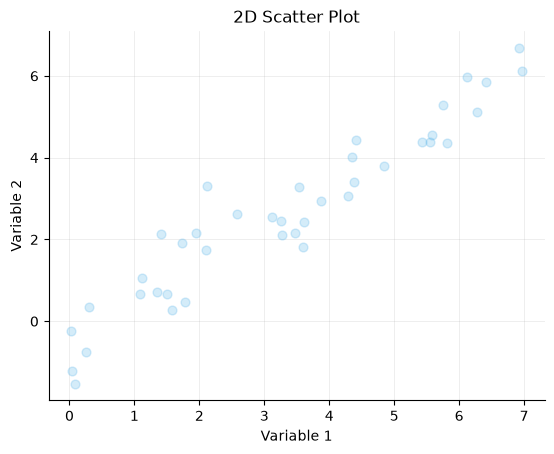

In [2]:
x = rng.uniform(0, 7, 40)
y = 0.8 * x + rng.normal(0, 0.8, 40)

ax = plt.gca()
make_scatter(x, y, ax, get_next_color(ax))
plt.show()

## 2. Options: transparency, custom axis and series labels

`alpha=` overrides the 0.25 default (useful for small samples, where fewer
points overlap); `xlabel=` / `ylabel=` rename the axes; `label=` names the
series in the legend once there is more than one.

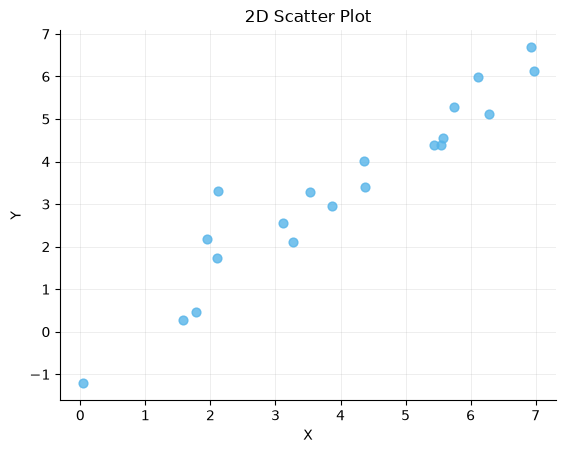

In [3]:
ax = plt.gca()
make_scatter(x[:20], y[:20], ax, get_next_color(ax), alpha=0.8, xlabel="X", ylabel="Y")
plt.show()

## 3. Overlay behavior — mimicking two `.plot()` calls

A second scatter on the same axes picks up the next Okabe-Ito color (orange)
and turns on the "Variable k" legend automatically. The open circles and low
alpha should keep the overlap region readable — you can still trace each cloud
through the other.

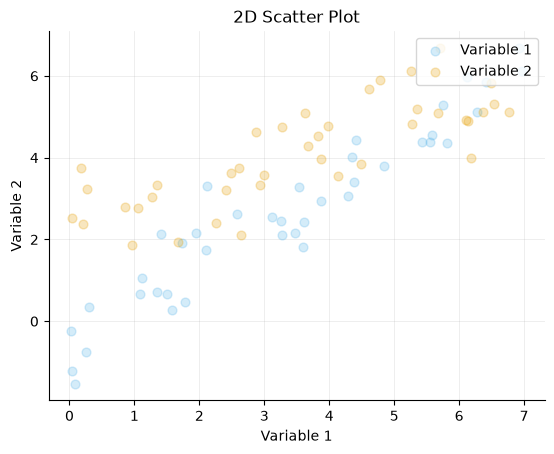

In [4]:
x2 = rng.uniform(0, 7, 40)
y2 = 0.5 * x2 + rng.normal(2.5, 0.8, 40)

ax = plt.gca()
make_scatter(x, y, ax, get_next_color(ax))
make_scatter(x2, y2, ax, get_next_color(ax))
plt.show()

## 4. With real symbulate simulation data

Same draft, but the data comes from an actual 2D `RV(...).sim(...)` call —
a bivariate normal with correlation 0.7, so the cloud should tilt clearly.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

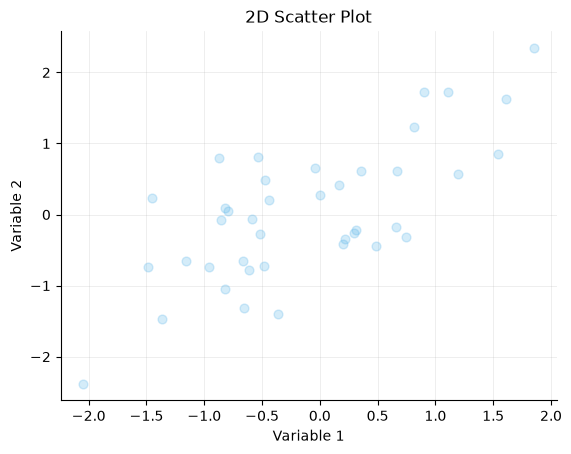

In [5]:
from symbulate import RV, BivariateNormal

sims = RV(BivariateNormal(mean1=0, mean2=0, sd1=1, sd2=1, corr=0.7)).sim(40)
arr = np.asarray(sims.results)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_scatter(arr[:, 0], arr[:, 1], ax, get_next_color(ax))
plt.show()

## 5. Discrete x Discrete: spiral jitter on the grid crossings

For two discrete variables, many points land on the exact same integer
`(x, y)`, so a plain scatter collapses them into one dot and random jitter
(`jitter=True`) scrambles the density. `jitter="spiral"` instead forms a tight
**compass cluster** centered on the value's grid crossing — the first point dead
center on the crossing, the next four on the grid lines at N/E/S/W, the next four
at the diagonals (NE, SE, NW, SW). Neighboring dots touch — the spacing is the dot's own on-screen size, recomputed if the figure is resized — so a cluster always reads at natural dot size, never spread apart by the axis scale. The cluster hugs its crossing, so it reads as
one shared value (never as separate values) and you can read each value's density
by counting its dots.

Compare the two cells below: random jitter first, then spiral.

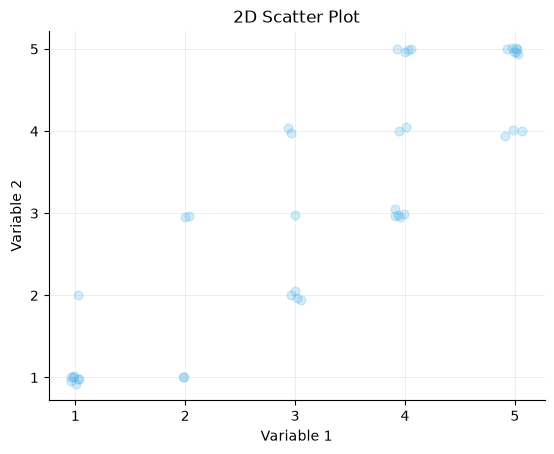

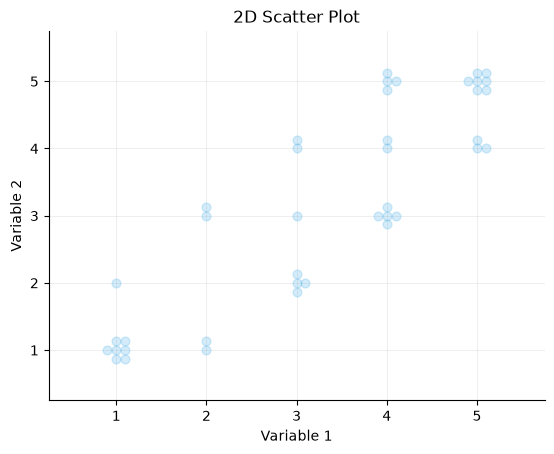

In [6]:
# Positively correlated integer data (e.g. two dependent discrete counts).
xd = rng.integers(1, 6, 40)
yd = np.clip(xd + rng.integers(-1, 2, 40), 1, 5)

# Random jitter: reduces overplotting but the density is impossible to read.
ax = plt.gca()
make_scatter(xd, yd, ax, get_next_color(ax), jitter=True)
plt.show()

# Spiral jitter: coincident points form tight countable compass clusters
# (center, then N/E/S/W, then the diagonals) sitting on the grid crossings.
ax = plt.gca()
make_scatter(xd, yd, ax, get_next_color(ax), jitter="spiral")
plt.show()

## 6. Spiral jitter on real symbulate discrete data

The discrete parallel of section 4: the data comes from an actual 2D discrete
`RV(...).sim(...)` — two independent `Binomial(6, 0.5)` counts, so probability
piles up in the central cells. With `jitter="spiral"`, the busy middle values
fill the countable compass cluster while the corner values hold just a point or two,
making the joint distribution's shape readable at a glance.

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

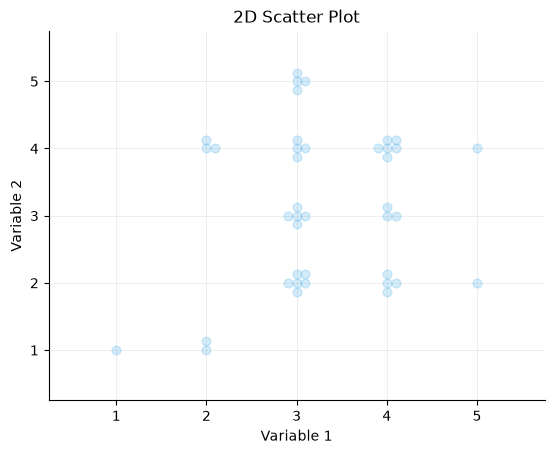

In [7]:
from symbulate import RV, Binomial

# Two independent Binomial(6, 0.5) counts -> a 2D discrete simulation.
disc_sims = RV(Binomial(6, 0.5) ** 2).sim(40)
disc = np.asarray(disc_sims.results)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_scatter(disc[:, 0], disc[:, 1], ax, get_next_color(ax), jitter="spiral")
plt.show()

## 7. Heavy pile-ups: `jitter="bins"` and `jitter="auto"`

The spiral compass template only holds 9 dots, so a big pile-up stops being cleanly
countable. `jitter="bins"` switches to a **histogram-style** reading instead: the
grid lines move to the half-integer bin edges, so each value gets a visible box with
its axis label centered inside (the way a histogram centers a bar over its bin), and
the points sharing a value fill their box **from the bottom-left corner — left to
right, then up a row — dots touching**, like a tiny dot histogram. The block is kept
square-ish (about √k dots wide) so a pile-up reads as a compact countable block, and
it never crosses its box's edges. A fuller box means a bigger count.

`jitter="auto"` reads the data first: once any single value holds
`SCATTER_AUTO_BINS_THRESHOLD` (12) or more points it uses the bins layout and prints a
note saying so; otherwise it draws the spiral. The data below is skewed so that
(0, 0) collects well past the threshold — compare the spiral pile-up, the explicit
bins request, and what auto does.

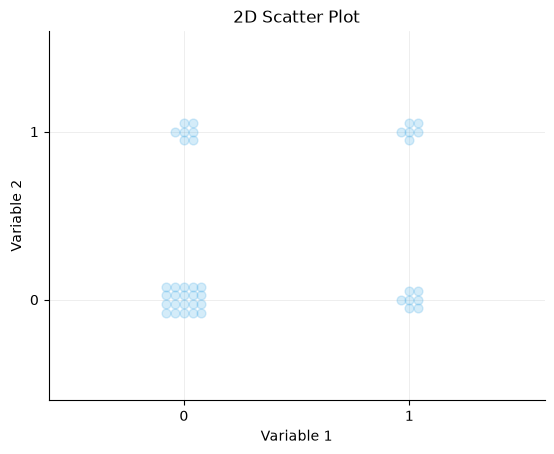

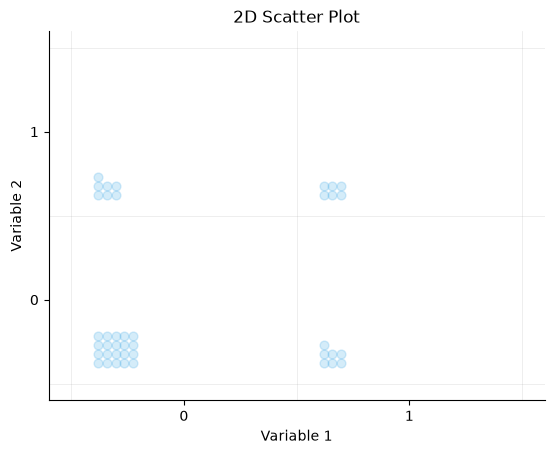

The most repeated value appears 20 times -- too many for the tight cluster style to stay countable -- so the points are spread across each value's bin (jitter='bins'). Pass jitter='spiral' to force tight clusters instead.


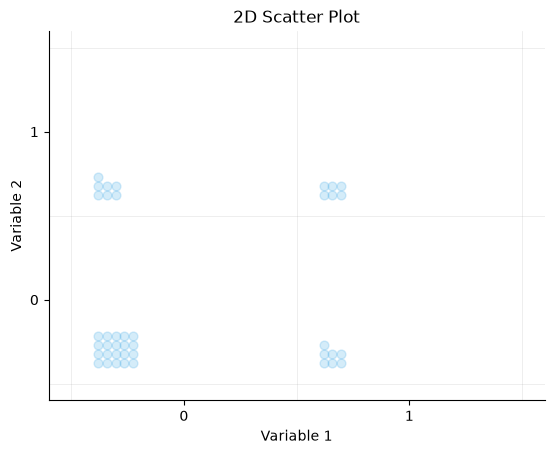

In [8]:
# Skewed discrete data: about half the 40 points land on (0, 0).
xh = rng.binomial(2, 0.15, 40)
yh = rng.binomial(2, 0.2, 40)

# Spiral on a heavy pile-up: the fixed-size cluster fuses into a blob.
ax = plt.gca()
make_scatter(xh, yh, ax, get_next_color(ax), jitter="spiral")
plt.show()

# Bins, requested explicitly: grid lines move to the half-integer bin
# edges so each value gets a box with its label centered inside, and
# the pile-up spreads orderly across its box -- separated and countable.
ax = plt.gca()
make_scatter(xh, yh, ax, get_next_color(ax), jitter="bins")
plt.show()

# Auto: sees the 12+ pile-up, prints a note, and draws the same bins
# layout without being asked.
ax = plt.gca()
make_scatter(xh, yh, ax, get_next_color(ax), jitter="auto")
plt.show()

## 8. A fuller grid: one heavy value among many light ones

Real discrete simulations usually mix both regimes in one plot: a mode that piles up
and a long tail of values holding just a point or two. Here 20 of the 40 points land
on (3, 3) and the other 20 scatter across a 1–6 support, so a dozen-plus distinct
values share the axes. `jitter="auto"` sees the 20-point pile-up and uses the bins
layout for the whole plot — the heavy box shows its square-ish bottom-left block
while the light values sit as one or two touching dots in their own boxes, and with
six values per axis the boxes are small enough that the dots fill them naturally at
the default figure size.

17 distinct values
The most repeated value appears 20 times -- too many for the tight cluster style to stay countable -- so the points are spread across each value's bin (jitter='bins'). Pass jitter='spiral' to force tight clusters instead.


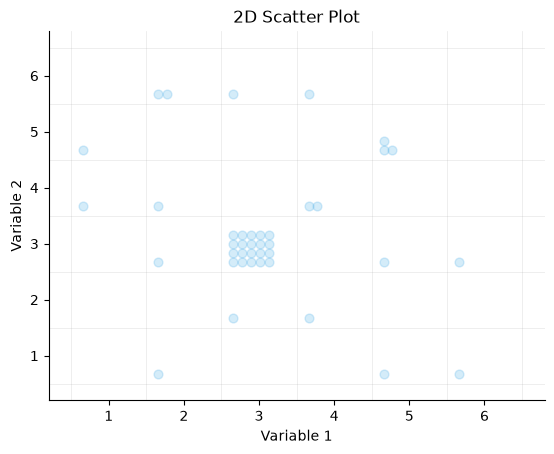

In [9]:
# One heavy value plus a wide spread: 20 points pile on (3, 3), the
# other 20 scatter across values 1-6 with only a point or two each.
xw = np.concatenate([np.full(20, 3), rng.integers(1, 7, 20)])
yw = np.concatenate([np.full(20, 3), rng.integers(1, 7, 20)])
print(f"{len(np.unique(np.column_stack([xw, yw]), axis=0))} distinct values")

ax = plt.gca()
make_scatter(xw, yw, ax, get_next_color(ax), jitter="auto")
plt.show()

## Verification checklist

- [ ] Section 1 matches the approved prototype image (sky blue, upward trend, no legend)
- [ ] Points are filled circles in the series color; overlap regions stay readable
- [ ] Grid behind the points, horizontal and vertical; no top/right spines
- [ ] `alpha=`, `xlabel=`, `ylabel=`, and `label=` overrides work
- [ ] Overlaid scatters get distinct Okabe-Ito colors and the automatic "Variable k" legend
- [ ] Works on real 2D `.sim()` output, not just numpy arrays
- [ ] Correlated bivariate normal data shows a clearly tilted cloud
- [ ] `jitter="spiral"`: grid lines pass through the cluster centers — every cluster sits on its own grid crossing
- [ ] Spiral clusters fill center-first, then N/E/S/W, then the diagonals, tight enough to read as one value; busy values are visibly fuller than sparse ones
- [ ] Spiral layout is deterministic — re-running gives the identical arrangement
- [ ] Section 7: `jitter="auto"` prints the switch note on the 12+ pile-up and spreads that cluster across its bin, every dot separated; small clusters keep the tight compass
- [ ] Bins mode: grid lines sit on the half-integer box edges with each value label centered in its box (histogram-style); spiral keeps grid lines through the cluster centers
- [ ] Dots inside spiral and bins clusters touch each other at natural dot size — never spread apart or shrunken by the axis scale
- [ ] Bins fill starts at the box's bottom-left corner and works left to right, then upward, in a compact square-ish block
- [ ] `jitter="bins"`/`"auto"` never spread a cluster past its box edges
- [ ] Section 8: the heavy value's block and the one-or-two-dot values read together on one 6-value grid, every cluster inside its own box